# Tip Data

## Description

A waiter recorded information about every tip he received over the course of several months working at a single restaurant.

## Format

A data table with 244 rows and 7 variables

## Details

- tip in dollars,
- bill in dollars,
- gender of the person paying the bill,
- whether there were smokers in the group,
- day of the week,
- time of day,
- group size.

In total, he recorded 244 tips. The data were published in a collection of case studies for business statistics (Bryant & Smith 1995).

### References

Bryant, P. G. and Smith, M (1995) Practical Data Analysis: Case Studies in Business Statistics. Homewood, IL: Richard D. Irwin Publishing:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset("tips")

In [4]:
df['sex']=df['sex'].astype('category')
df['smoker']=df['smoker'].astype('category')
df['day']=df['day'].astype('category')
df['time']=df['time'].astype('category')
print(*df.dtypes)

float64 float64 category category category category int64


In [5]:
print(*df.isna().any())

False False False False False False False


In [6]:
df.sort_values(by='tip').head()

,total_bill,tip,sex,smoker,day,time,size
92,5.75,1.00,Female,Yes,Fri,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
67,3.07,1.00,Female,Yes,Sat,Dinner,1
236,12.60,1.00,Male,Yes,Sat,Dinner,2
0,16.99,1.01,Female,No,Sun,Dinner,2


In [7]:
df.sort_values(by='total_bill', ascending = False).head(3)

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4


## Univariate non-graphical exploratory data analysis

In [8]:
df.describe(include=['category'])

,sex,smoker,day,time
count,244,244,244,244
unique,2,2,4,2
top,Male,No,Sat,Dinner
freq,157,151,87,176


In [9]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


# Correlations

# 1. Total bill [USD] vs. Tips [USD]

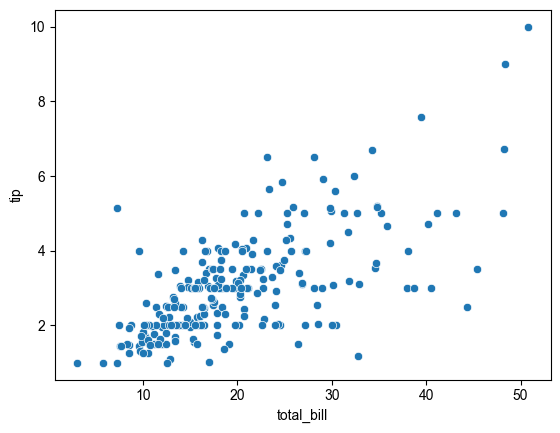

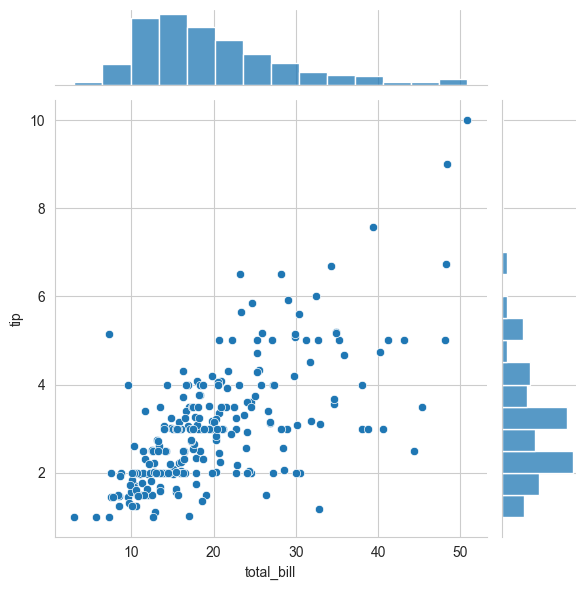

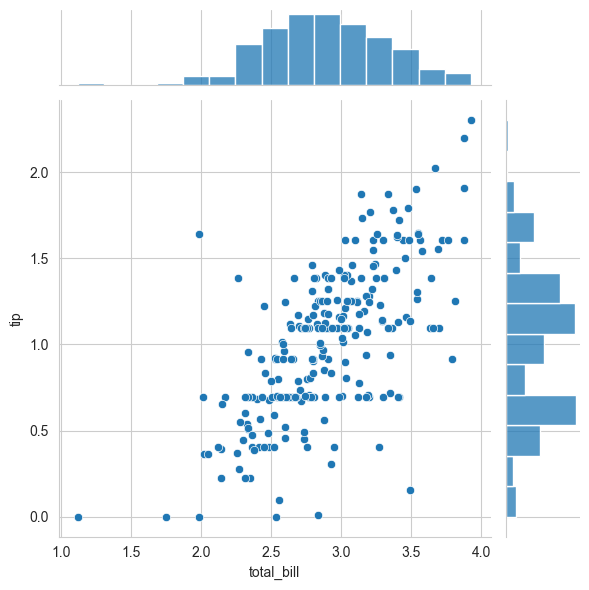

In [10]:
from scipy.stats import pearsonr
sns.scatterplot(x='total_bill', y='tip', data=df)
sns.set_style('whitegrid')

sns.jointplot(x='total_bill', y='tip', data=df)

log_total_bill = np.log(df['total_bill'])
log_tipp = np.log(df['tip'])


sns.jointplot(x=log_total_bill, y=log_tipp, data=df)
plt.show()

In [11]:
pearsonr(log_total_bill, log_tipp)

PearsonRResult(statistic=np.float64(0.6795702560274505), pvalue=np.float64(2.079456516537212e-34))

# 2. Tips [USD] vs. Group size

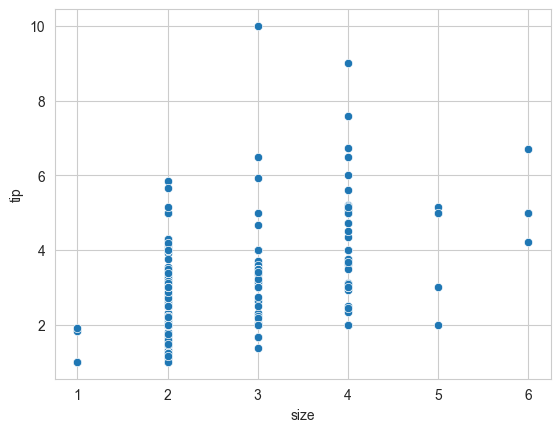

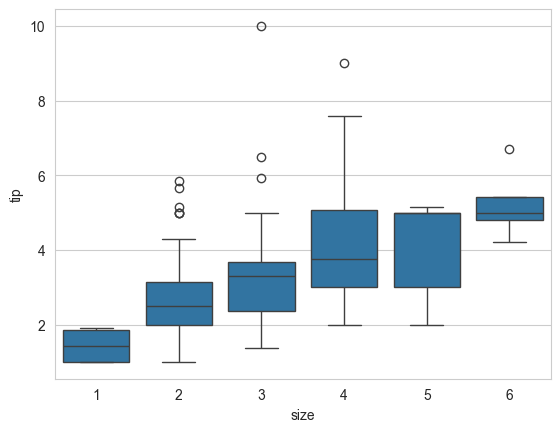

<Axes: xlabel='size', ylabel='tip'>

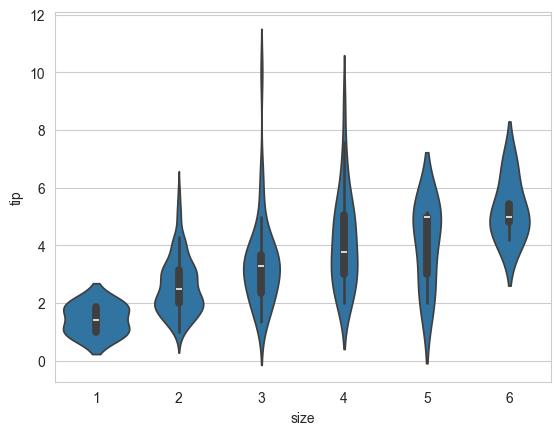

In [12]:
sns.scatterplot(x='size' , y='tip', data=df)

plt.show()
sns.boxplot(x='size', y='tip', data=df)

plt.show()

sns.violinplot(x='size', y='tip', data=df)

In [13]:
from scipy.stats import kendalltau, spearmanr

kendalltau(df['size'], df['tip']) # this coorelatio is used for ordinal data ex 1,2,3,4,5
#spearmanr(df['size'], df['tip']) # this correlation is used for non linear data 

SignificanceResult(statistic=np.float64(0.3781847296598378), pvalue=np.float64(7.302407699520677e-14))

# 3. Using the tips dataset, investigate the association between pairs of categorical variables.

Select suitable pairs of qualitative variables (e.g., sex, smoker, day, time) and:

- Create contingency tables.
- Visualize the relationships using count plots or stacked bar charts.
- Perform a Chi-square test of independence.
- Calculate an appropriate measure of association for categorical variables:
  - Phi coefficient (for 2×2 tables)
  - Cramér’s V (for larger contingency tables)
- Interpret the strength and practical meaning of the relationships.

<Axes: xlabel='time', ylabel='count'>

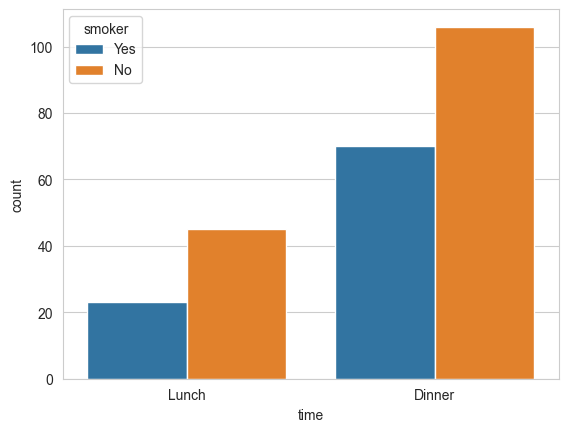

In [14]:
sns.countplot(data=df, x='time', hue = 'smoker')

In [15]:
ct1 = pd.crosstab( df['smoker'], df['time'])

In [16]:
from scipy.stats import chi2_contingency

chi2_contingency(ct1)

Chi2ContingencyResult(statistic=np.float64(0.5053733928754355), pvalue=np.float64(0.4771485672079724), dof=1, expected_freq=array([[ 25.91803279,  67.08196721],
       [ 42.08196721, 108.91803279]]))

In [17]:
from scipy.stats.contingency import association

association(ct1) #only for 2x2 tables
#for larger tables we can use  method = 'cramers' 

0.054921103595707566

In [18]:
ct2 = pd.crosstab( df['smoker'], df['day'])

<Axes: xlabel='day', ylabel='count'>

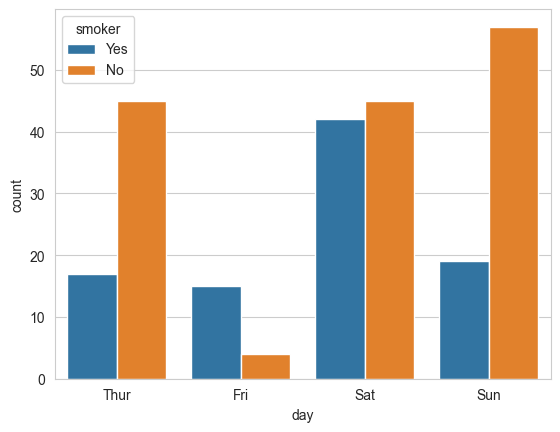

In [19]:
chi2_contingency(ct2)
sns.countplot(data=df, x='day', hue = 'smoker')

<Axes: xlabel='sex', ylabel='count'>

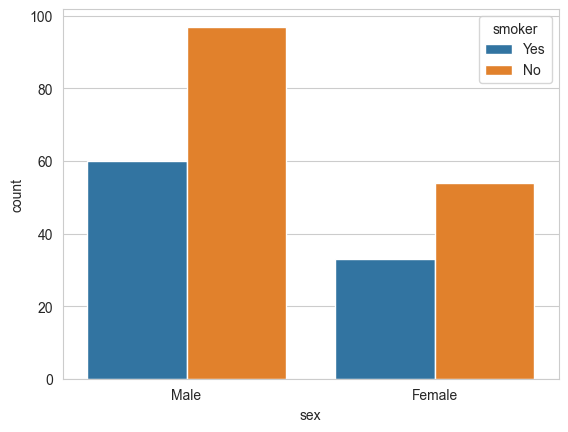

In [20]:
ct3 = pd.crosstab( df['smoker'], df['sex'])
chi2_contingency(ct3)

sns.countplot(data=df, x ='sex', hue = 'smoker')

<Axes: xlabel='sex', ylabel='count'>

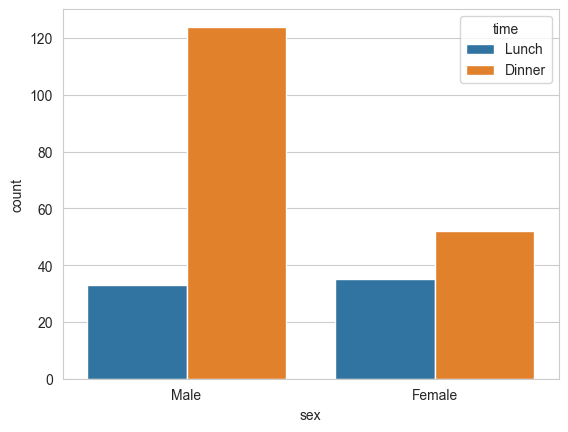

In [21]:
ct4 = pd.crosstab(df['sex'], df['time'])
chi2_contingency(ct4)

sns.countplot(data=df, x ='sex', hue = 'time')

In [22]:
# Total bills against time,, how it should be calculated, measured and visualized?

In [26]:
df.groupby('time')['total_bill'].describe()

C:\Users\simon\AppData\Local\Temp\ipykernel_31920\1293134793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('time')['total_bill'].describe()


,count,mean,std,min,25%,50%,75%,max
time,,,,,,,,
Lunch,68.0,17.168676,7.713882,7.51,12.2350,15.965,19.5325,43.11
Dinner,176.0,20.797159,9.142029,3.07,14.4375,18.390,25.2825,50.81


In [23]:
bills_against_time = df.groupby('time')['total_bill'].sum()
print(bills_against_time)

time
Lunch     1167.47
Dinner    3660.30
Name: total_bill, dtype: float64


C:\Users\simon\AppData\Local\Temp\ipykernel_31920\1296430463.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bills_against_time = df.groupby('time')['total_bill'].sum()


<Axes: xlabel='time'>

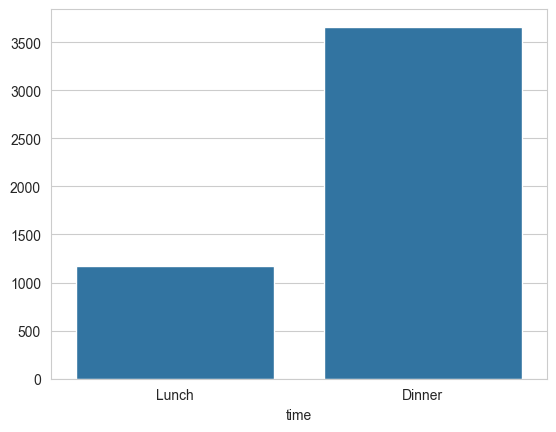

In [24]:
sns.barplot(x=bills_against_time.index, y=bills_against_time.values)

<Axes: xlabel='time', ylabel='total_bill'>

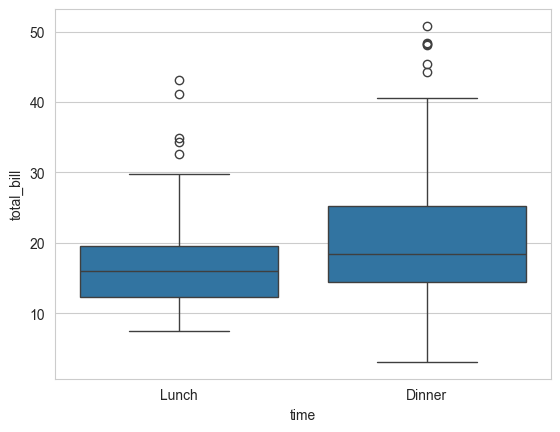

In [25]:
sns.boxplot(x='time', y='total_bill', data=df)